***Image Classification***

In [8]:
import zipfile
import os

zip_path = "/content/Image_Classification.zip"  # change if name differs
extract_path = "/content/Dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully")


✅ Dataset extracted successfully


In [10]:
import os
os.listdir('/content/Dataset')

['Day_13']

In [13]:
print("joker images:", len(os.listdir("/content/Dataset/Day_13/Dataset/train/joker")))
print("Thanos images:", len(os.listdir("/content/Dataset/Day_13/Dataset/train/thanos")))

joker images: 40
Thanos images: 40


**Train Model**

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [16]:
# Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [18]:
# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

In [19]:
val_datagen = ImageDataGenerator(rescale=1./255)

In [21]:
training_set = train_datagen.flow_from_directory(
    '/content/Dataset/Day_13/Dataset/train',
    target_size=(64,64),
    batch_size=8,
    class_mode='binary'
)

Found 80 images belonging to 2 classes.


In [22]:
val_set = val_datagen.flow_from_directory(
    '/content/Dataset/Day_13/Dataset/val',
    target_size=(64,64),
    batch_size=8,
    class_mode='binary'
)

Found 20 images belonging to 2 classes.


In [47]:
history = model.fit(
    training_set,
    steps_per_epoch=10,
    epochs=50,
    validation_data=val_set,
    validation_steps=2
)

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 207ms/step - accuracy: 0.9769 - loss: 0.0606 - val_accuracy: 1.0000 - val_loss: 0.0090
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 161ms/step - accuracy: 0.9769 - loss: 0.0450 - val_accuracy: 1.0000 - val_loss: 0.0156
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step - accuracy: 1.0000 - loss: 0.0192 - val_accuracy: 1.0000 - val_loss: 0.0031
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 169ms/step - accuracy: 1.0000 - loss: 0.0156 - val_accuracy: 1.0000 - val_loss: 0.0026
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step - accuracy: 1.0000 - loss: 0.0125 - val_accuracy: 1.0000 - val_loss: 0.0035
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 204ms/step - accuracy: 1.0000 - loss: 0.0167 - val_accuracy: 1.0000 - val_loss: 0.0033
Epoch 7/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 229ms/step - accuracy: 1.0000 - loss: 0.0264 - val_accuracy: 1.0000 - val_loss: 0.0019
Epoch 8/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - accuracy: 1.0000 - loss: 0.0187 - val_accuracy: 1.

In [27]:
# Save model
model_json = model.to_json()
with open("/content/model.json", "w") as json_file:
    json_file.write(model_json)

model.save_weights("/content/model.weights.h5")

print("✅ Model saved successfully")

✅ Model saved successfully


**Test Model**

In [28]:
import numpy as np
import os
from tensorflow.keras.models import model_from_json, Sequential
from tensorflow.keras.preprocessing import image

In [29]:
with open("/content/model.json", "r") as json_file:
    loaded_model_json = json_file.read()

model = model_from_json(
    loaded_model_json,
    custom_objects={"Sequential": Sequential}
)

In [31]:
model.load_weights("/content/model.weights.h5")
print("✅ Loaded model from disk")

✅ Loaded model from disk


In [53]:
# Classification function
def classify(img_file):
    test_image = image.load_img(img_file, target_size=(64,64))
    test_image = image.img_to_array(test_image)
    test_image = np.expand_dims(test_image, axis=0) / 255.0

    result = model.predict(test_image, verbose=0)
    if result[0][0] >= 0.5:
        prediction = "Thanos"
    else:
        prediction = "Joker"

    print(f"{prediction} : {os.path.basename(img_file)}")

In [35]:
# Test folder path (COLAB PATH)
test_path = "/content/Dataset/test"

for root, dirs, files in os.walk(test_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            classify(os.path.join(root, file))

In [37]:
import os

img_path = "/content/Dataset/Day_13/Dataset/test/joker1.jpeg"  # change filename
print("File exists:", os.path.exists(img_path))


File exists: True


(np.float64(-0.5), np.float64(1399.5), np.float64(2152.5), np.float64(-0.5))

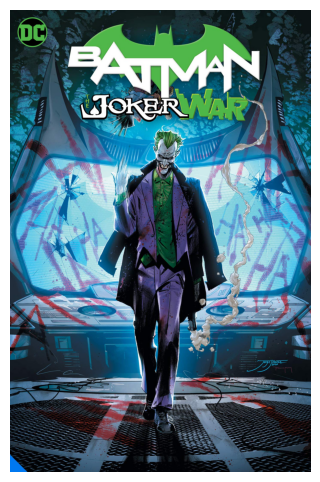

In [51]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img_path = "/content/Dataset/Day_13/Dataset/test/joker5.jpeg" # Corrected filename

img = image.load_img(img_path)  # NO resizing
plt.figure(figsize=(6,6))       # Increase size
plt.imshow(img)
plt.axis('off')

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 193ms/step - accuracy: 1.0000 - loss: 3.1484e-04 - val_accuracy: 1.0000 - val_loss: 1.4701e-04
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step - accuracy: 1.0000 - loss: 5.4979e-04 - val_accuracy: 1.0000 - val_loss: 1.3374e-04
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 283ms/step - accuracy: 1.0000 - loss: 5.1865e-04 - val_accuracy: 1.0000 - val_loss: 1.3470e-04
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step - accuracy: 1.0000 - loss: 6.4054e-04 - val_accuracy: 1.0000 - val_loss: 1.2213e-04
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - accuracy: 1.0000 - loss: 6.8651e-04 - val_accuracy: 1.0000 - val_loss: 1.2925e-04
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - accuracy: 1.0000 - loss: 5.5974e-04 - val_accuracy: 1.0000 - val_loss: 1.3432e-04
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - accuracy: 1.0000 - loss: 7.8985e-04 - val_accuracy: 1.0000 - val_loss: 1.0954e-04
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 162ms/s

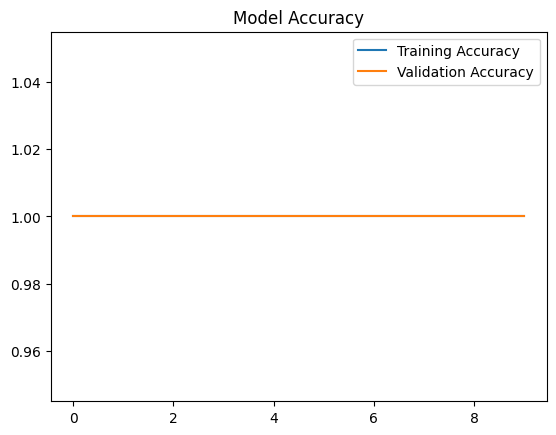

In [48]:
history = model.fit(
    training_set,
    epochs=10,
    validation_data=val_set
)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Model Accuracy")
plt.show()

In [62]:
print("Current image:", img_path)


Current image: /content/Dataset/Day_13/Dataset/test/joker5.jpeg


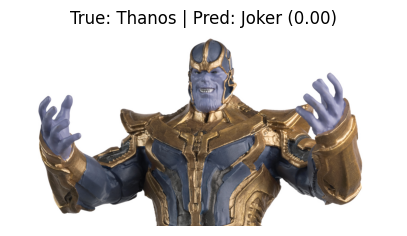

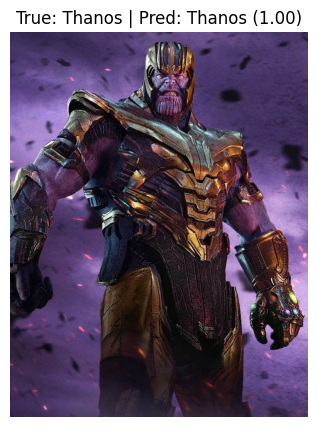

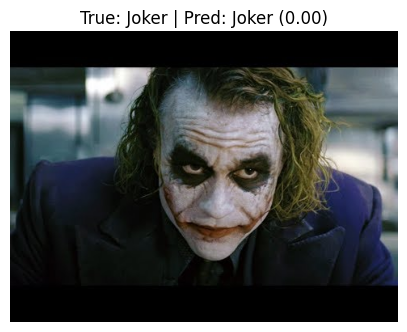

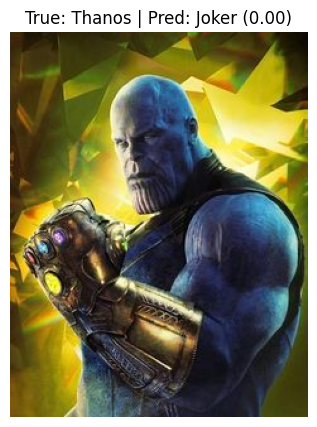

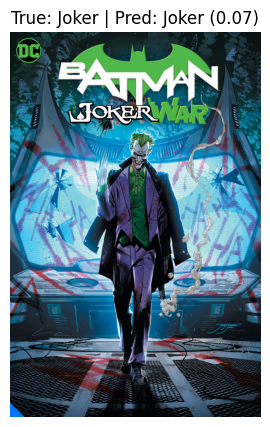

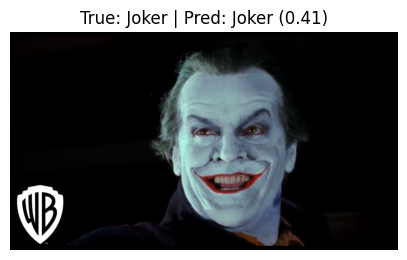

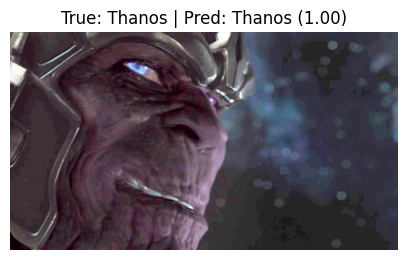

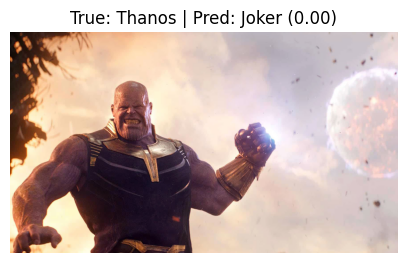

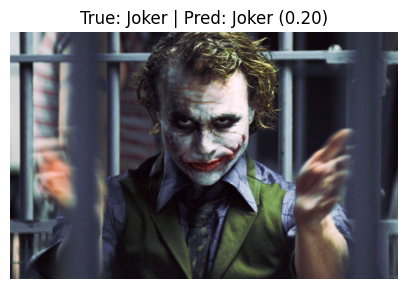

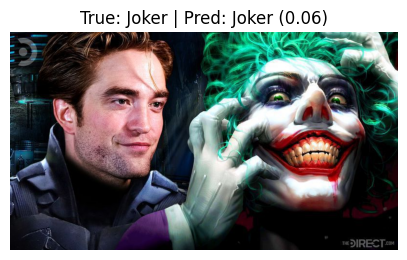

In [66]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

test_dir = "/content/Dataset/Day_13/Dataset/test"

# Map for predicted class index to name
class_labels_map = {0: 'Joker', 1: 'Thanos'}

for img_file_name in os.listdir(test_dir):
    img_path = os.path.join(test_dir, img_file_name)

    # Ensure it's a file and an image
    if os.path.isfile(img_path) and img_file_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
        # Infer true label from filename (e.g., 'joker1.jpeg' -> 'Joker')
        if 'joker' in img_file_name.lower():
            true_label = 'Joker'
        elif 'thanos' in img_file_name.lower():
            true_label = 'Thanos'
        else:
            true_label = 'Unknown'

        # Display original image
        img_display = Image.open(img_path)

        # Prepare for model
        img_model = image.load_img(img_path, target_size=(64,64))
        img_array = image.img_to_array(img_model) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Predict
        prediction = model.predict(img_array, verbose=0)
        pred_class_idx = int(prediction[0][0] >= 0.5)
        predicted_label = class_labels_map[pred_class_idx]

        # Show image + prediction
        plt.figure(figsize=(5,5))
        plt.imshow(img_display)
        plt.title(f"True: {true_label} | Pred: {predicted_label} ({prediction[0][0]:.2f})")
        plt.axis('off')
        plt.show()